# Clasificador Binario de Malware 

Este notebook implementa el pipeline de entrenamiento final para el **Intelligent Antivirus**. Se enfoca en la reproducibilidad, el alto rendimiento (HPC) y la trazabilidad de experimentos (MLOps).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import concurrent.futures
import time
import os
import json
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import joblib

%matplotlib inline
plt.style.use('dark_background')

# Crear directorios base si no existen
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("Entorno preparado.")

Entorno preparado.


## Pipeline de Datos Profesional
Limpieza, manejo de duplicados y forzado de desbalanceo (simulación de entorno real).

In [2]:
df = pd.read_csv('../data/raw/Obfuscated-MalMem2022.csv')

# 1. Limpieza de Hashes
df['Category'] = df['Category'].str.split('-').str[:2].str.join('-')
df.drop_duplicates(inplace=True)

# 2. Varianza Cero (Remover columnas constantes)
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=const_cols, inplace=True)

# 3. Mapeo
df['Class'] = df['Class'].map({'Benign': 0, 'Malware': 1})

# 4. Forzar Desbalanceo (Escenario Real: 20% Malware)
df_benign = df[df['Class'] == 0]
df_malware = df[df['Class'] == 1]
df_malware_sampled = df_malware.sample(frac=0.2, random_state=42)
df_final = pd.concat([df_benign, df_malware_sampled]).sample(frac=1, random_state=42)

print(f"Dataset final preparado: {df_final.shape}")
print(df_final['Class'].value_counts(normalize=True))

Dataset final preparado: (34994, 54)
Class
0    0.835315
1    0.164685
Name: proportion, dtype: float64


## Entrenamiento Paralelo
Entrenamos un RandomForest utilizando todos los núcleos disponibles.

In [3]:
X = df_final.select_dtypes(include=[np.number]).drop(columns=['Class'])
y = df_final['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Iniciando entrenamiento paralelo...")
start_train = time.time()

# n_jobs=-1 activa el paralelismo de Scikit-Learn (Joblib)
model = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

t_train = time.time() - start_train
print(f"Entrenamiento completado en: {t_train:.4f}s")

Iniciando entrenamiento paralelo...
Entrenamiento completado en: 0.8934s


## Evaluación y MLOps
Generamos artefactos de reporte y exportamos el modelo oficial.

AUC-ROC: 1.0000


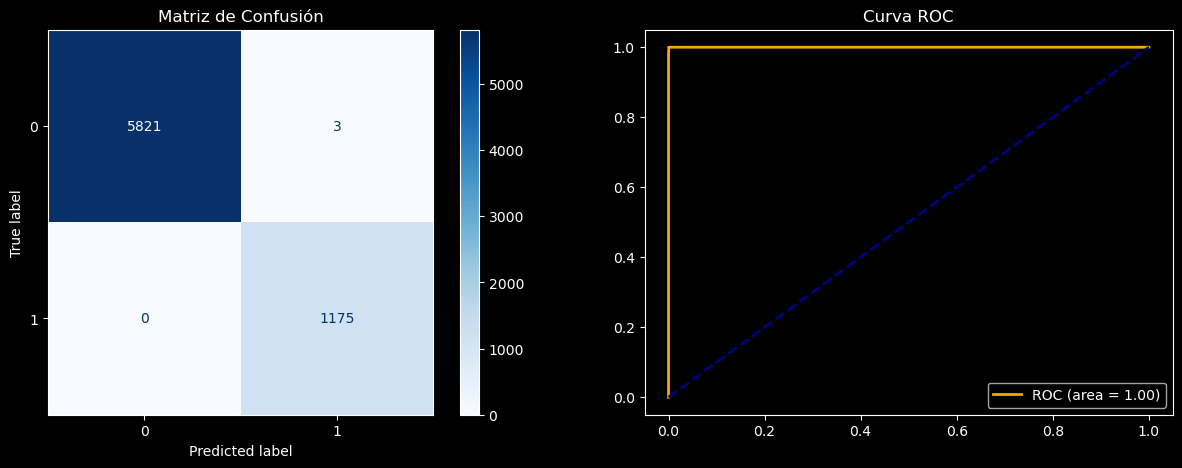

✅ Modelo exportado a models/model.pkl
📁 Reportes generados en ../reports/run_20260428_171426


In [4]:
# 1. Generar Carpeta de Ejecución
run_id = datetime.now().strftime("run_%Y%m%d_%H%M%S")
run_dir = f"../reports/{run_id}"
os.makedirs(run_dir, exist_ok=True)

# 2. Métricas
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
report_dict = classification_report(y_test, y_pred, output_dict=True)

print(f"AUC-ROC: {auc_score:.4f}")

# 3. Visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax1, cmap='Blues')
ax1.set_title("Matriz de Confusión")

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color='orange', lw=2, label=f'ROC (area = {auc_score:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_title("Curva ROC")
ax2.legend()

plt.savefig(f"{run_dir}/metrics_viz.png")
plt.show()

# 4. Guardar Reporte JSON
final_report = {
    "run_id": run_id,
    "metrics": report_dict,
    "auc_roc": auc_score,
    "hpc_train_time": t_train,
    "model_params": model.get_params()
}

with open(f"{run_dir}/report.json", 'w') as f:
    json.dump(final_report, f, indent=4)

# 5. Exportar Modelo Oficial
joblib.dump(model, '../models/model.pkl')
print(f"✅ Modelo exportado a models/model.pkl")
print(f"📁 Reportes generados en {run_dir}")